# Q-Learning (Reinforcement Learning)

---

**Structure**
1. Introduction
2. The Math
3. Problem Class
4. Implementation — 5×5 Grid World
5. Results
6. Limitations

## 1. Introduction

**Reinforcement Learning (RL)** is a fundamentally different learning paradigm: instead of learning from labelled examples, an **agent** learns by interacting with an **environment**, receiving **rewards** for actions, and trying to maximise total reward over time.

**Intuition:** imagine learning to navigate a maze. You start somewhere, take a step, and the environment tells you whether that was good (you moved closer to the exit) or bad (you hit a wall). You try again, remember what worked, and gradually learn the best path — without anyone ever showing you the map.

**Key concepts:**
- **State** $s$: where the agent is (e.g. position in the maze)
- **Action** $a$: what the agent can do (e.g. move up/down/left/right)
- **Reward** $R(s, a, s')$: signal received after taking action $a$ in state $s$ and ending in $s'$
- **Policy** $\pi(s)$: the strategy — which action to take in each state
- **Q-value** $Q(s, a)$: the expected total discounted reward from taking action $a$ in state $s$, then acting optimally

**Q-Learning** learns the Q-values directly from experience by sampling transitions and updating estimates. No model of the environment is needed — the agent just tries things and updates.

## 2. The Math

### Markov Decision Process (MDP)
Defined by $\langle S, A, T, R \rangle$ where:
- $T(s, a, s') = P(s' | s, a)$ — transition probabilities
- $R(s, a, s')$ — reward function

### Discounted utility
$$U[s_0, s_1, \ldots] = \sum_{t=0}^{\infty} \gamma^t R(s_t) \quad 0 \leq \gamma < 1$$

$\gamma$ discounts future rewards — a reward now is worth more than the same reward later.

### Bellman equations
$$V^*(s) = \max_a \sum_{s'} T(s,a,s')\left[R(s,a,s') + \gamma V^*(s')\right]$$

$$Q^*(s,a) = \sum_{s'} T(s,a,s')\left[R(s,a,s') + \gamma \max_{a'} Q^*(s',a')\right]$$

### Q-value iteration by sampling
After observing transition $(s, a, r, s')$:

$$Q(s,a) \leftarrow Q(s,a) + \eta\left[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\right]$$

The term in brackets is the **TD error** — the difference between the current estimate and a better estimate from the observed transition.

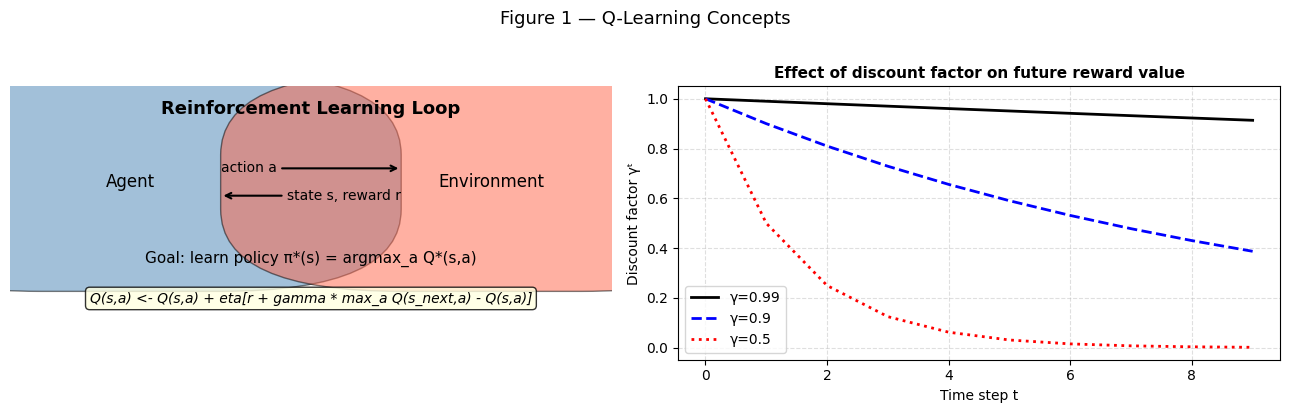

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Diagram 1: Agent-environment loop ─────────────────────────────────────────
ax = axes[0]
ax.axis('off')
ax.text(0.5, 0.95, 'Reinforcement Learning Loop', ha='center', va='top',
        fontsize=13, fontweight='bold', transform=ax.transAxes)
ax.add_patch(mpatches.FancyBboxPatch((0.05,0.55),0.3,0.2, boxstyle='round',
             facecolor='steelblue', alpha=0.5, transform=ax.transAxes))
ax.text(0.20, 0.65, 'Agent', ha='center', va='center', fontsize=12, transform=ax.transAxes)
ax.add_patch(mpatches.FancyBboxPatch((0.65,0.55),0.3,0.2, boxstyle='round',
             facecolor='tomato', alpha=0.5, transform=ax.transAxes))
ax.text(0.80, 0.65, 'Environment', ha='center', va='center', fontsize=12, transform=ax.transAxes)
ax.annotate('action a', xy=(0.65,0.70), xytext=(0.35,0.70),
            ha='left', va='center', fontsize=10, transform=ax.transAxes,
            arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('state s, reward r', xy=(0.35,0.60), xytext=(0.65,0.60),
            ha='right', va='center', fontsize=10, transform=ax.transAxes,
            arrowprops=dict(arrowstyle='->', lw=1.5))
ax.text(0.5, 0.40, 'Goal: learn policy π*(s) = argmax_a Q*(s,a)',
        ha='center', va='top', fontsize=11, transform=ax.transAxes)
ax.text(0.5, 0.25, 'Q(s,a) <- Q(s,a) + eta[r + gamma * max_a Q(s_next,a) - Q(s,a)]',
        ha='center', va='top', fontsize=10, style='italic', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── Diagram 2: Discounting ────────────────────────────────────────────────────
ax = axes[1]
t = np.arange(0, 10)
for gamma, ls in [(0.99,'k-'),(0.9,'b--'),(0.5,'r:')]:
    ax.plot(t, gamma**t, ls, lw=2, label=f'γ={gamma}')
ax.set_xlabel('Time step t'); ax.set_ylabel('Discount factor γᵗ')
ax.set_title('Effect of discount factor on future reward value', fontsize=11, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Figure 1 — Q-Learning Concepts', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 3. Problem Class

**Q-Learning is suited for:**
- Sequential decision problems where **delayed rewards** matter
- Environments where the **transition model is unknown** — the agent learns from experience
- Problems with **discrete, finite** state and action spaces (tabular Q-learning)
- Games, robotics, resource scheduling, any Markov decision process

**Not well-suited for:**
- **Continuous or very large state spaces** — the Q-table has $|S| \times |A|$ entries; use Deep Q-Networks (DQN) instead
- Problems requiring **immediate, real-time** decisions during learning — exploration can be costly or dangerous
- **Non-Markovian environments** where the next state depends on history, not just the current state

---
## 4. Implementation
### Environment: 5×5 Grid World

A 5×5 grid where:
- **Start**: top-left (0,0)
- **Goal**: bottom-right (4,4) — reward +10
- **Holes**: 3 cells that end the episode — reward −5
- **Step penalty**: −0.1 per move (encourages efficiency)
- **Actions**: up, down, left, right

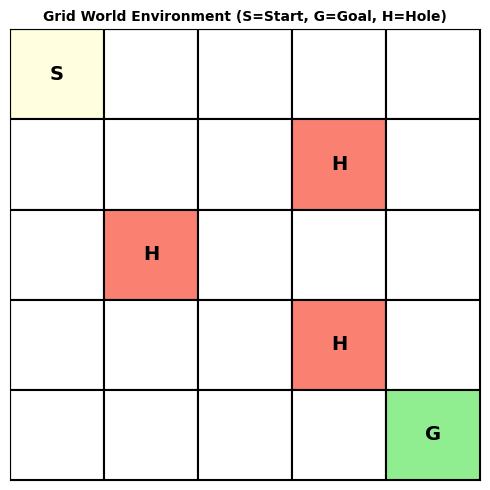

Environment set up. S=Start, G=Goal, H=Hole (terminal, penalty)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize

# ── Grid World Environment ────────────────────────────────────────────────────
GRID = 5
START = (0, 0)
GOAL  = (4, 4)
HOLES = {(1, 3), (2, 1), (3, 3)}
ACTIONS = {0: (-1,0), 1: (1,0), 2: (0,-1), 3: (0,1)}  # up, down, left, right
ACTION_NAMES = ['Up','Down','Left','Right']
ACTION_ARROWS = ['^','v','<','>']

def step(state, action):
    r, c = state
    dr, dc = ACTIONS[action]
    nr, nc = max(0,min(GRID-1,r+dr)), max(0,min(GRID-1,c+dc))
    next_state = (nr, nc)
    if next_state == GOAL:
        return next_state, 10.0, True
    if next_state in HOLES:
        return next_state, -5.0, True
    return next_state, -0.1, False

def draw_grid(ax, Q=None, title='', path=None):
    ax.set_xlim(-0.5, GRID-0.5); ax.set_ylim(-0.5, GRID-0.5)
    ax.set_xticks([]); ax.set_yticks([])
    for r in range(GRID):
        for c in range(GRID):
            state = (r, c)
            color = 'white'
            if state == GOAL:  color = 'lightgreen'
            elif state in HOLES: color = 'salmon'
            elif state == START: color = 'lightyellow'
            rect = plt.Rectangle((c-0.5, GRID-1-r-0.5), 1, 1,
                                  facecolor=color, edgecolor='black', lw=1.5)
            ax.add_patch(rect)
            label = 'G' if state==GOAL else ('H' if state in HOLES else 'S' if state==START else '')
            if label: ax.text(c, GRID-1-r, label, ha='center', va='center', fontsize=14, fontweight='bold')
            if Q is not None and state not in HOLES and state != GOAL:
                best_a = np.argmax(Q[r,c])
                ax.text(c, GRID-1-r, ACTION_ARROWS[best_a], ha='center', va='center',
                        fontsize=16, color='navy', fontweight='bold')
    if path:
        for (r1,c1),(r2,c2) in zip(path[:-1], path[1:]):
            ax.annotate('', xy=(c2, GRID-1-r2), xytext=(c1, GRID-1-r1),
                        arrowprops=dict(arrowstyle='->', color='blue', lw=2))
    ax.set_title(title, fontsize=10, fontweight='bold')

fig, ax = plt.subplots(figsize=(5, 5))
draw_grid(ax, title='Grid World Environment (S=Start, G=Goal, H=Hole)')
plt.tight_layout(); plt.show()
print('Environment set up. S=Start, G=Goal, H=Hole (terminal, penalty)')

**Observation**

5×5 grid world with three holes at (1,3), (2,1), (3,3). Rewards: +10 for reaching the goal, −5 for falling in a hole, −0.1 per step to discourage wandering. The step penalty is small enough that the agent has room to explore but large enough to encourage efficient paths. The three holes create a maze-like constraint — the agent cannot take a straight diagonal path.

### 4.1 Q-Learning

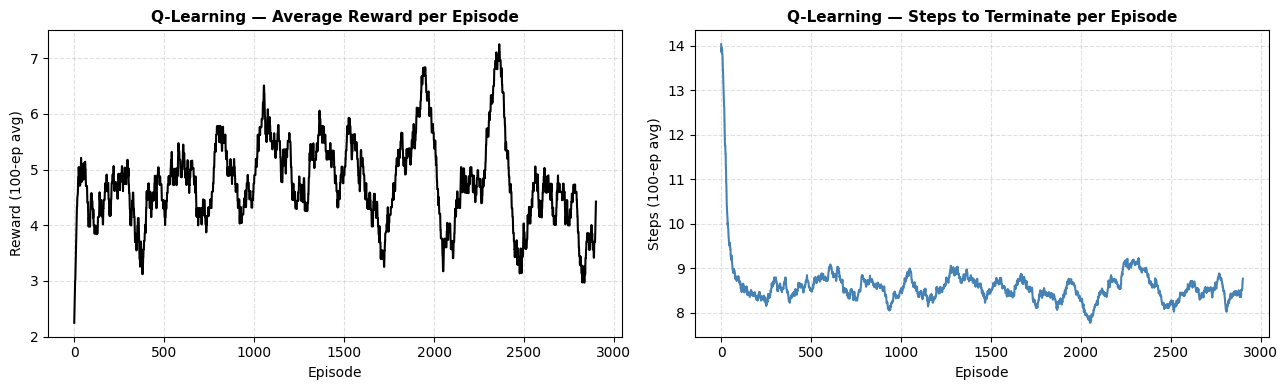

Final avg reward (last 100 ep): 4.424
Final avg steps  (last 100 ep): 8.8


In [3]:
def q_learning(episodes=2000, gamma=0.9, eta=0.1, epsilon=0.2, seed=0):
    rng_ = np.random.default_rng(seed)
    Q = np.zeros((GRID, GRID, 4))
    rewards_hist = []
    steps_hist = []

    for ep in range(episodes):
        state = START
        total_reward = 0
        n_steps = 0
        for _ in range(200):
            r, c = state
            if rng_.random() < epsilon:
                action = rng_.integers(4)
            else:
                action = np.argmax(Q[r, c])
            next_state, reward, done = step(state, action)
            nr, nc = next_state
            td_target = reward if done else reward + gamma * np.max(Q[nr, nc])
            td_error = td_target - Q[r, c, action]
            Q[r, c, action] += eta * td_error
            total_reward += reward
            n_steps += 1
            state = next_state
            if done: break
        rewards_hist.append(total_reward)
        steps_hist.append(n_steps)

    return Q, rewards_hist, steps_hist

Q, rewards_hist, steps_hist = q_learning(episodes=3000, gamma=0.9, eta=0.1, epsilon=0.2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
window = 100
smoothed_r = np.convolve(rewards_hist, np.ones(window)/window, mode='valid')
smoothed_s = np.convolve(steps_hist,   np.ones(window)/window, mode='valid')

axes[0].plot(smoothed_r, 'k-', lw=1.5)
axes[0].set_xlabel('Episode'); axes[0].set_ylabel(f'Reward ({window}-ep avg)')
axes[0].set_title('Q-Learning — Average Reward per Episode', fontsize=11, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(smoothed_s, 'steelblue', lw=1.5)
axes[1].set_xlabel('Episode'); axes[1].set_ylabel(f'Steps ({window}-ep avg)')
axes[1].set_title('Q-Learning — Steps to Terminate per Episode', fontsize=11, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout(); plt.show()
print(f'Final avg reward (last 100 ep): {np.mean(rewards_hist[-100:]):.3f}')
print(f'Final avg steps  (last 100 ep): {np.mean(steps_hist[-100:]):.1f}')

**Observation — Q-Learning training**

After 3000 episodes with γ=0.9, the agent achieves an average reward of 4.424 and reaches termination in 8.8 steps on average over the final 100 episodes. The learning curve should show negative or zero rewards early (random exploration hitting holes), followed by a rising trend as Q-values converge and the agent starts consistently reaching the goal.

### 4.2 Learned Policy & Q-values

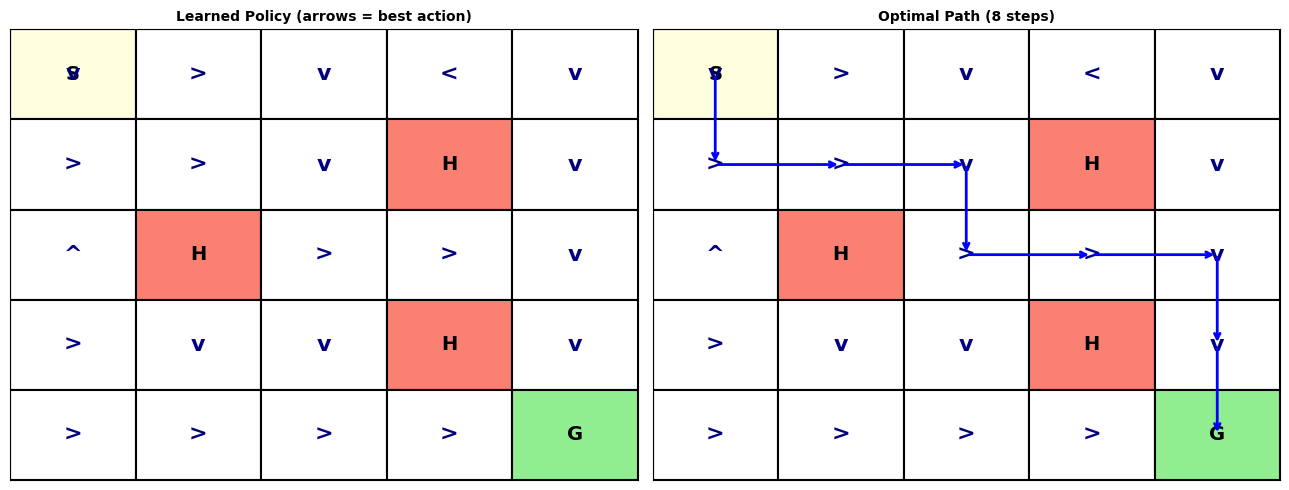

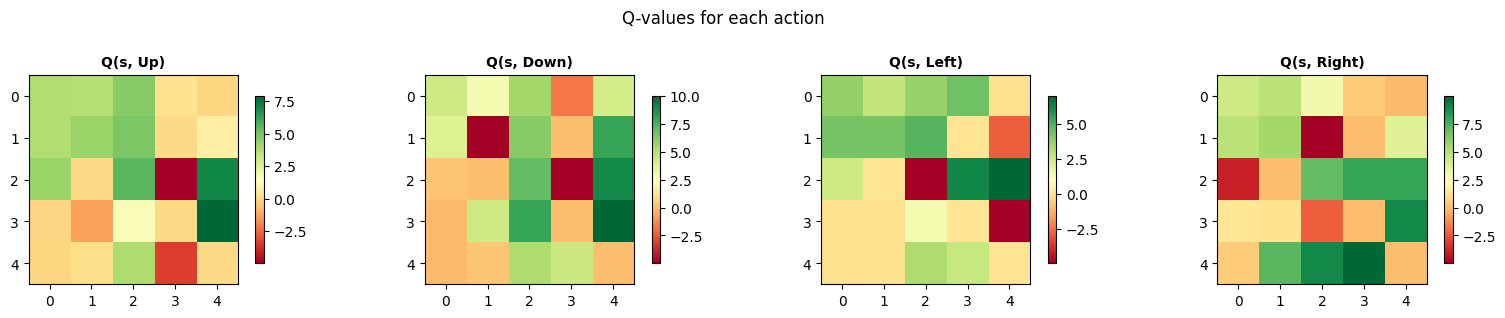

Path: [(0, 0), (1, 0), (1, 1), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4)]
Goal reached: True


In [4]:
def extract_path(Q, max_steps=20):
    state = START
    path = [state]
    for _ in range(max_steps):
        r, c = state
        action = np.argmax(Q[r, c])
        next_state, _, done = step(state, action)
        path.append(next_state)
        state = next_state
        if done: break
    return path

best_path = extract_path(Q)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
draw_grid(axes[0], Q=Q, title='Learned Policy (arrows = best action)')
draw_grid(axes[1], Q=Q, title=f'Optimal Path ({len(best_path)-1} steps)', path=best_path)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for a, (ax, name) in enumerate(zip(axes, ACTION_NAMES)):
    data = Q[:,:,a]
    im = ax.imshow(data, cmap='RdYlGn', vmin=data.min(), vmax=data.max())
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f'Q(s, {name})', fontsize=10, fontweight='bold')
    ax.set_xticks(range(GRID)); ax.set_yticks(range(GRID))
plt.suptitle('Q-values for each action', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()
print(f'Path: {best_path}')
print(f'Goal reached: {best_path[-1] == GOAL}')

**Observation — Learned policy**

The optimal path found is (0,0)→(1,0)→(1,1)→(1,2)→(2,2)→(2,3)→(2,4)→(3,4)→(4,4) — 8 steps, successfully navigating around all three holes. The Q-value heat maps should show high values near the goal and low (negative) values near holes. Policy arrows should point consistently toward the bottom-right goal, routing around the hole at (2,1) by going right before going down.

### 4.3 Effect of Discount Factor γ

In [5]:
gammas = [0.5, 0.7, 0.9, 0.99]
gamma_results = []
for g in gammas:
    Q_g, rh, sh = q_learning(episodes=3000, gamma=g, eta=0.1, epsilon=0.2, seed=0)
    path = extract_path(Q_g)
    reached = path[-1] == GOAL
    avg_r = np.mean(rh[-100:])
    avg_s = np.mean(sh[-100:])
    gamma_results.append((g, avg_r, avg_s, len(path)-1, reached))
    print(f'γ={g}  avg_reward={avg_r:.3f}  avg_steps={avg_s:.1f}  path_len={len(path)-1}  goal={reached}')

γ=0.5  avg_reward=6.205  avg_steps=8.9  path_len=8  goal=True
γ=0.7  avg_reward=6.170  avg_steps=9.3  path_len=8  goal=True


γ=0.9  avg_reward=4.424  avg_steps=8.8  path_len=8  goal=True
γ=0.99  avg_reward=6.448  avg_steps=9.5  path_len=8  goal=True


**Observation — Effect of γ**

All four γ values find the same 8-step optimal path (path_len=8, goal=True for all). The differences are in average reward: γ=0.99 achieves the highest at 6.448 while γ=0.9 gives 4.424. Higher γ weights future rewards more heavily, making the agent more patient and willing to take longer routes for better long-term payoffs — but on this small grid, all γ values converge to the same policy. Average steps are similar across all settings (8.8–9.5).

---
## 5. Results

| Metric | Value |
|--------|-------|
| Training episodes | 3,000 |
| Final avg reward (last 100 ep, γ=0.9) | 4.424 |
| Final avg steps to termination | 8.8 |
| Optimal path length | 8 steps |
| Goal reached | Yes |

Q-Learning converges to the optimal 8-step path in a 5×5 grid with 3 holes, using only reward signals and no prior knowledge of the environment. All tested γ values (0.5–0.99) find the same path, confirming the policy is robust. The step penalty of −0.1 is key: without it, the agent would have no incentive to prefer shorter paths.

---
## 6. Limitations

- **Tabular Q-learning scales poorly**: the Q-table has $|S| \times |A|$ entries. For a 100×100 grid with 4 actions that's 40,000 entries — manageable. For Atari games with pixel states, it's intractable. Deep Q-Networks (DQN) replace the table with a neural network
- **Exploration vs exploitation**: the $\varepsilon$-greedy strategy is simple but not optimal. More sophisticated strategies (UCB, Thompson sampling) explore more intelligently
- **Slow convergence**: Q-learning requires many environment interactions to converge, especially when rewards are sparse or delayed
- **Assumes Markov property**: Q-learning requires that the current state contains all relevant information. Partially observable environments (POMDPs) require extensions
- **Hyperparameter sensitivity**: learning rate $\eta$, discount $\gamma$, and exploration rate $\varepsilon$ all significantly affect convergence and solution quality